<a href="https://colab.research.google.com/github/mentor-pranaya/Cricket-Player-Performance-Prediction/blob/akshaya/Milestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/cricket_ml/batsman_features.csv')

df.head()


,season,batter,matches_played,avg_runs_last_5,avg_sr_last_5,career_avg_runs,runs
0,2012,A Ashish Reddy,1,10.00,100.0,10.00,10
1,2012,A Ashish Reddy,2,6.50,100.0,6.50,3
2,2012,A Ashish Reddy,3,7.00,100.0,7.00,8
3,2012,A Ashish Reddy,4,7.75,137.5,7.75,10
4,2012,A Ashish Reddy,5,7.00,126.0,7.00,4


Check columns

In [3]:
df.columns


Index(['season', 'batter', 'matches_played', 'avg_runs_last_5',
       'avg_sr_last_5', 'career_avg_runs', 'runs'],
      dtype='object')

In [5]:
print(df.columns)


Index(['season', 'batter', 'matches_played', 'avg_runs_last_5',
       'avg_sr_last_5', 'career_avg_runs', 'runs'],
      dtype='object')


In [6]:
df = df.sort_values(['batter','season']).reset_index(drop=True)


In [7]:
df['baseline_10_match_avg'] = (
    df.groupby('batter')['runs']
      .shift(1)
      .rolling(10)
      .mean()
)


In [8]:
baseline_df = df.dropna(subset=['baseline_10_match_avg']).copy()


In [9]:
baseline_df.head()


,season,batter,matches_played,avg_runs_last_5,avg_sr_last_5,career_avg_runs,runs,baseline_10_match_avg
10,2013,A Ashish Reddy,11,11.2,115.222222,8.909091,19,7.9
11,2013,A Ashish Reddy,12,9.8,111.888889,8.750000,7,8.8
12,2013,A Ashish Reddy,13,16.4,141.888889,10.846154,36,9.2
13,2013,A Ashish Reddy,14,16.0,131.787879,11.071429,14,12.0
14,2013,A Ashish Reddy,15,16.2,130.073593,10.666667,5,12.4


In [13]:
feature_cols = [
    'matches_played',
    'avg_runs_last_5',
    'avg_sr_last_5',
    'career_avg_runs'
]


Sort data

In [14]:
df = df.sort_values(['batter','season']).reset_index(drop=True)


Baseline model

In [15]:
df['baseline_10_match_avg'] = (
    df.groupby('batter')['runs']
      .shift(1)
      .rolling(10)
      .mean()
)

baseline_df = df.dropna(subset=['baseline_10_match_avg']).copy()


Train/Test Split

In [16]:
split_index = int(len(baseline_df) * 0.8)

train_df = baseline_df.iloc[:split_index]
test_df  = baseline_df.iloc[split_index:]


Baseline Evaluation

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_test = test_df['runs']
y_pred_baseline = test_df['baseline_10_match_avg']

rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
mae  = mean_absolute_error(y_test, y_pred_baseline)
r2   = r2_score(y_test, y_pred_baseline)

rmse, mae, r2


(np.float64(22.61747608875986), 17.17445923460898, 0.022054860397668463)

Prepare ML feature

In [18]:
feature_cols = [
    'avg_runs_last_5',
    'avg_sr_last_5',
    'career_avg_runs',
    'matches_played'
]

X = baseline_df[feature_cols]
y = baseline_df['runs']

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


Random Forrest Model

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

Evaluate Random Forest Model

In [20]:
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

rmse_rf, mae_rf, r2_rf


(np.float64(19.911585779462964), 14.889775374376041, 0.24205461838129194)

XG Boost model

In [21]:
!pip install xgboost


In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluate XGBoost

In [23]:
y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

rmse_xgb, mae_xgb, r2_xgb


(np.float64(19.449647499165554), 14.556374549865723, 0.2768145203590393)

LightGBM model

In [24]:
!pip install lightgbm


In [25]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgb_model.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000694 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 993
[LightGBM] [Info] Number of data points in the train set: 9616, number of used features: 4
[LightGBM] [Info] Start training from score 21.860649


LGBMRegressor(learning_rate=0.05, n_estimators=300, random_state=42)

In [26]:
y_pred_lgb = lgb_model.predict(X_test)

rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb  = mean_absolute_error(y_test, y_pred_lgb)
r2_lgb   = r2_score(y_test, y_pred_lgb)

rmse_lgb, mae_lgb, r2_lgb


(np.float64(19.562522514383875), 14.665999149775036, 0.26839625096079767)

Hyperparameter tuning (GridSearchCV – Random Forest)

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[150, 300],
    'max_depth':[5, 10, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42,n_jobs=-1),
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error'
)

grid.fit(X_train, y_train)


GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             param_grid={'max_depth': [5, 10, None],
                         'n_estimators': [150, 300]},
             scoring='neg_mean_squared_error')

In [28]:
best_rf = grid.best_estimator_
grid.best_params_


{'max_depth': 5, 'n_estimators': 300}

Evaluate tuned Random Forest

In [29]:
y_pred_best_rf = best_rf.predict(X_test)

rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))
mae_best_rf  = mean_absolute_error(y_test, y_pred_best_rf)
r2_best_rf   = r2_score(y_test, y_pred_best_rf)

rmse_best_rf, mae_best_rf, r2_best_rf


(np.float64(19.152426036460447), 14.399310004192253, 0.29874850431972233)

SHAP feature

In [30]:
!pip install shap


In [31]:
import shap


In [32]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)


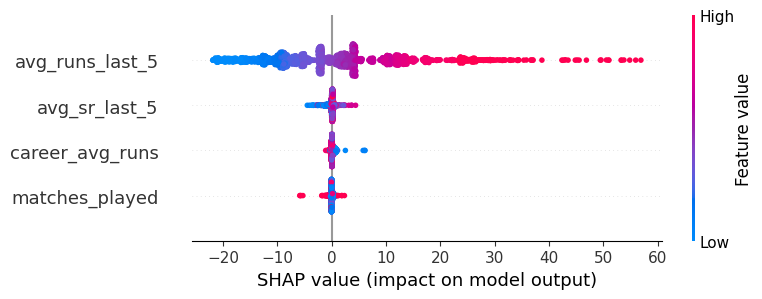

In [33]:
shap.summary_plot(shap_values, X_test)


In [34]:
import joblib


In [35]:
joblib.dump(best_rf,
             '/content/drive/MyDrive/cricket_ml/best_rf_model.pkl')

joblib.dump(xgb,
             '/content/drive/MyDrive/cricket_ml/xgb_model.pkl')

joblib.dump(lgb_model,
             '/content/drive/MyDrive/cricket_ml/lgb_model.pkl')


['/content/drive/MyDrive/cricket_ml/lgb_model.pkl']

In [36]:
results = pd.DataFrame({
    'Model':['Baseline',
             'RandomForest',
             'Tuned RandomForest',
             'XGBoost',
             'LightGBM'],
    'RMSE':[rmse, rmse_rf, rmse_best_rf, rmse_xgb, rmse_lgb],
    'MAE' :[mae,  mae_rf,  mae_best_rf,  mae_xgb,  mae_lgb],
    'R2'  :[r2,   r2_rf,   r2_best_rf,   r2_xgb,  r2_lgb]
})

results


,Model,RMSE,MAE,R2
0,Baseline,22.617476,17.174459,0.022055
1,RandomForest,19.911586,14.889775,0.242055
2,Tuned RandomForest,19.152426,14.399310,0.298749
3,XGBoost,19.449647,14.556375,0.276815
4,LightGBM,19.562523,14.665999,0.268396


In [37]:
results.to_csv('/content/drive/MyDrive/cricket_ml/model_results.csv',
               index=False)
